# Smart Data Explorer

## Setup: Import Libraries

These libraries are used for making data, scaling, clustering, ANN training, timing, tables and graphs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, silhouette_score

warnings.filterwarnings("ignore")

## Part 1: Dataset Selection

I used sample numeric data because the main purpose here is to compare clustering and ANN. The dataset satisfies the requirement of 100 to 500 samples and 2 to 5 features.

In [2]:
np.random.seed(7)

x, y = make_classification(
    n_samples=220,
    n_features=5,
    n_informative=4,
    n_redundant=1,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=7
)

mydata = pd.DataFrame(x, columns=["feature1", "feature2", "feature3", "feature4", "feature5"])
mydata["label"] = y

print(mydata.head())
print("total rows:", mydata.shape[0])
print("total features:", 5)

   feature1  feature2  feature3  feature4  feature5  label
0  0.892506 -0.328347  0.435895 -1.002928 -0.141942      2
1 -2.432959  1.971078 -0.972865  1.003446 -0.285890      1
2  0.486618 -1.527951  2.139319 -1.060432 -0.318125      2
3  0.793457 -0.321320  0.680949 -0.662097  0.184156      2
4 -4.665329 -3.300945 -0.653517 -2.527241 -7.500560      0
total rows: 220
total features: 5


### Part 1.1: Separate Input and Output

In this step I separated input features and target labels. Input features are used for clustering and ANN training.

In [3]:
xdata = mydata.drop("label", axis=1)
ydata = mydata["label"]

scale = StandardScaler()
xscaled = scale.fit_transform(xdata)

print("scaling done")

scaling done


## Part 2: Clustering Module

### Part 2.1: Run K Means for Different K Values

I tried different cluster values. Inertia tells how close points are inside clusters. Silhouette score tells how good the cluster separation is.

### Clustering

K Means is an unsupervised learning algorithm. It makes groups of similar data points using distance.

In this project, I used K Means to find groups in the dataset. I tested different values of K because choosing K is important.

Intra-cluster similarity means points inside the same cluster should be close to each other. In this notebook, I used inertia for this.

Inter-cluster separation means different clusters should be well separated from each other. In this notebook, I used silhouette score for this.


In [4]:
klist = [2, 3, 4, 5, 6]
answer = []

for k in klist:
    km = KMeans(n_clusters=k, random_state=7, n_init=1, max_iter=50)
    klabel = km.fit_predict(xscaled)

    innerdistance = km.inertia_
    silscore = silhouette_score(xscaled, klabel)

    answer.append([k, innerdistance, silscore])

ktable = pd.DataFrame(answer, columns=["k", "inner distance", "silhouette score"])
print(ktable)

   k  inner distance  silhouette score
0  2      818.431617          0.289077
1  3      489.221089          0.374016
2  4      392.620269          0.346944
3  5      352.696899          0.291718
4  6      305.708342          0.288004


### Part 2.2: Visualize Clustering Scores

These graphs help me see which value of K is reasonable.

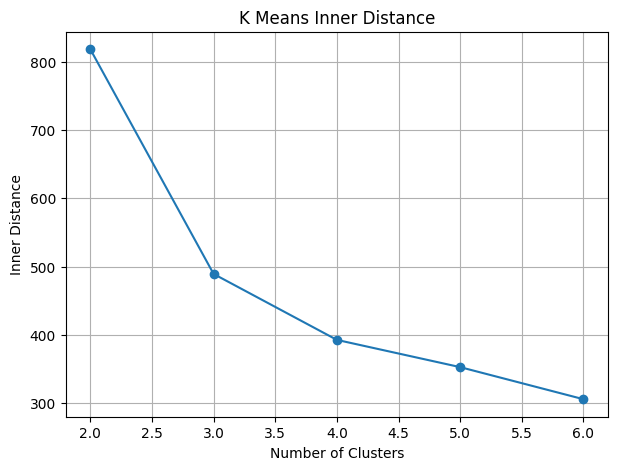

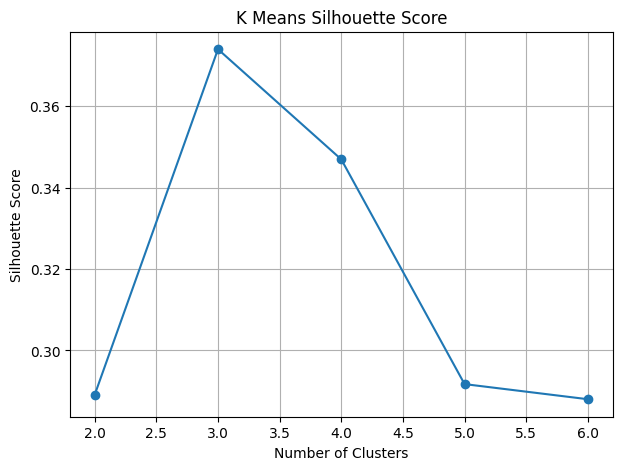

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(ktable["k"], ktable["inner distance"], marker="o")
plt.title("K Means Inner Distance")
plt.xlabel("Number of Clusters")
plt.ylabel("Inner Distance")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(ktable["k"], ktable["silhouette score"], marker="o")
plt.title("K Means Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

### Part 2.3: Final K Means Clustering

I selected the final value of K and stored the cluster number in the data frame.

In [6]:
bestk = 3

kmfinal = KMeans(n_clusters=bestk, random_state=7, n_init=1, max_iter=50)
kmcluster = kmfinal.fit_predict(xscaled)

mydata["kmeans cluster"] = kmcluster

print(mydata.head())
print("K Means completed")

   feature1  feature2  feature3  feature4  feature5  label  kmeans cluster
0  0.892506 -0.328347  0.435895 -1.002928 -0.141942      2               0
1 -2.432959  1.971078 -0.972865  1.003446 -0.285890      1               1
2  0.486618 -1.527951  2.139319 -1.060432 -0.318125      2               0
3  0.793457 -0.321320  0.680949 -0.662097  0.184156      2               0
4 -4.665329 -3.300945 -0.653517 -2.527241 -7.500560      0               2
K Means completed


### Part 2.4: Visualize Clusters in 2D using PCA

The actual data has multiple features, so it cannot be drawn directly in 2D. I used PCA to convert it into 2 values only for plotting.

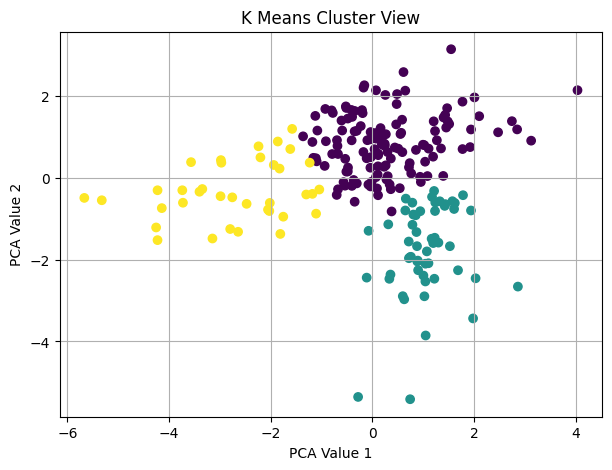

In [7]:
pca = PCA(n_components=2)
xview = pca.fit_transform(xscaled)

plt.figure(figsize=(7, 5))
plt.scatter(xview[:, 0], xview[:, 1], c=kmcluster)
plt.title("K Means Cluster View")
plt.xlabel("PCA Value 1")
plt.ylabel("PCA Value 2")
plt.grid(True)
plt.show()

### Part 2.5: K Medoids Clustering
 It chooses some real data points as medoids and then improves them step by step.

### K Means and K Medoids Difference

K Means uses the average center of a cluster. This center may not be an actual data point.

K Medoids uses real data points as centers. These real center points are called medoids.

I used K Medoids as a comparison method with K Means.


In [8]:
def distance(a, b):
    value = np.sqrt(np.sum((a - b) ** 2))
    return value


def mykmedoids(values, k, rounds):
    rowcount = values.shape[0]
    chosen = np.random.choice(rowcount, k, replace=False)
    medoids = values[chosen]

    for r in range(rounds):
        groups = []

        for row in values:
            distlist = []

            for medoid in medoids:
                distlist.append(distance(row, medoid))

            groups.append(np.argmin(distlist))

        groups = np.array(groups)
        newmedoids = []

        for groupno in range(k):
            grouprows = values[groups == groupno]

            if len(grouprows) == 0:
                newmedoids.append(medoids[groupno])
            else:
                alldist = grouprows[:, None, :] - grouprows[None, :, :]
                alldist = np.sqrt(np.sum(alldist ** 2, axis=2))
                costlist = np.sum(alldist, axis=1)
                bestplace = np.argmin(costlist)
                bestrow = grouprows[bestplace]
                newmedoids.append(bestrow)

        newmedoids = np.array(newmedoids)

        if np.allclose(medoids, newmedoids):
            break

        medoids = newmedoids

    return groups, medoids

### Part 2.6: Run K Medoids

 K Medoids function and checked its silhouette score.

In [9]:
np.random.seed(7)

medoidcluster, medoids = mykmedoids(xscaled, 3, 10)
mydata["kmedoids cluster"] = medoidcluster

medoidscore = silhouette_score(xscaled, medoidcluster)

print("K Medoids silhouette score:", medoidscore)
print(mydata.head())

K Medoids silhouette score: 0.3625142905775068
   feature1  feature2  feature3  ...  label  kmeans cluster  kmedoids cluster
0  0.892506 -0.328347  0.435895  ...      2               0                 2
1 -2.432959  1.971078 -0.972865  ...      1               1                 1
2  0.486618 -1.527951  2.139319  ...      2               0                 2
3  0.793457 -0.321320  0.680949  ...      2               0                 2
4 -4.665329 -3.300945 -0.653517  ...      0               2                 0

[5 rows x 8 columns]


### Part 2.7: Compare Clustering Results

This table compares clustering methods using silhouette score. It helps in checking cluster separation.

In [10]:
kmeansscore = silhouette_score(xscaled, kmcluster)

clustertable = pd.DataFrame({
    "method": ["K Means", "K Medoids"],
    "silhouette score": [kmeansscore, medoidscore]
})

print(clustertable)

      method  silhouette score
0    K Means          0.374016
1  K Medoids          0.362514


## Part 3: Using Clusters Intelligently

### Option 2: Feature Augmentation

I selected feature augmentation. I added the K Means cluster number as a new feature with the original scaled features. Then I trained ANN again on this improved dataset.

### Why I Selected Feature Augmentation

For Part 3, I selected Option 2 that is Feature Augmentation.

In this method, the cluster number produced by K Means is added as a new input feature. This gives ANN one extra column that represents the group of each data point.

So the ANN is trained on original features plus the cluster feature.


In [13]:
xwithcluster = np.column_stack((xscaled, kmcluster))

xtrain2, xtest2, ytrain2, ytest2 = train_test_split(
    xwithcluster,
    ydata,
    test_size=0.25,
    random_state=7
)

start = time.time()

ann2 = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=300,
    random_state=7
)

ann2.fit(xtrain2, ytrain2)

end = time.time()

pred2 = ann2.predict(xtest2)
ann2acc = accuracy_score(ytest2, pred2)
ann2time = end - start

print("ANN with cluster accuracy:", ann2acc)
print("ANN with cluster training time:", ann2time)

ANN with cluster accuracy: 0.9818181818181818
ANN with cluster training time: 0.10715651512145996


## Part 4: Neural Network MLP

### Part 4.1: ANN Only

Now I trained a simple ANN directly on the scaled features and checked its accuracy.

### Required ANN Theory

#### Perceptron

A perceptron is the basic unit of an artificial neural network. It takes input features, multiplies them with weights, adds bias and then passes the result through an activation function.



output = activation(weighted sum + bias)

In this project, the MLP model uses many perceptrons inside hidden layers.

#### Forward Pass

Forward pass means the input data moves from the input layer to the hidden layer and then to the output layer.

In this project, the ANN takes the dataset features as input and predicts the class label. When cluster feature is added, the ANN takes original features plus cluster ID as input.

#### Backpropagation

Backpropagation is the learning process of ANN. First, the model makes a prediction. Then it checks the error between predicted output and actual output. After that, it updates weights to reduce the error.

This process repeats many times during training.

#### Activation Function

Activation function helps the neural network learn non-linear patterns. Without activation functions, the neural network would behave almost like a simple linear model.

In this notebook, I used ReLU in the main ANN model because it is simple, fast and commonly used in hidden layers.

I also tested other activation functions like tanh and logistic to compare their effect on accuracy.


In [11]:
xtrain, xtest, ytrain, ytest = train_test_split(
    xscaled,
    ydata,
    test_size=0.25,
    random_state=7
)

start = time.time()

ann = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=500,
    random_state=7
)

ann.fit(xtrain, ytrain)

end = time.time()

pred = ann.predict(xtest)
annacc = accuracy_score(ytest, pred)
anntime = end - start

print("ANN accuracy:", annacc)
print("ANN training time:", anntime)

ANN accuracy: 0.9818181818181818
ANN training time: 0.1617138385772705


### Part 4.2: Training Loss Graph for ANN Only

This graph shows how the loss changed during training.

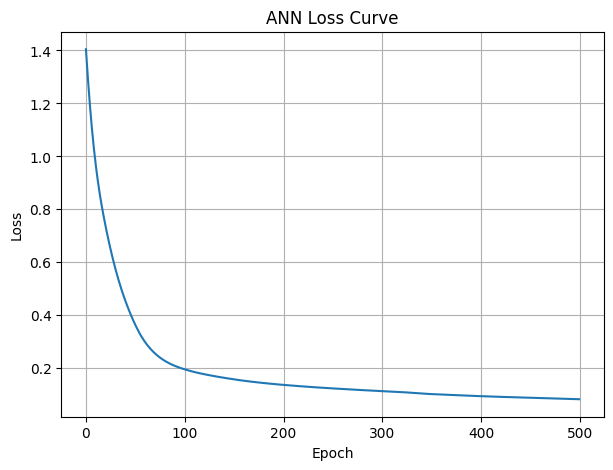

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(ann.loss_curve_)
plt.title("ANN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Part 4.3: Training Loss Graph for ANN with Cluster Feature

This graph is for the ANN model where cluster number was also added as input.

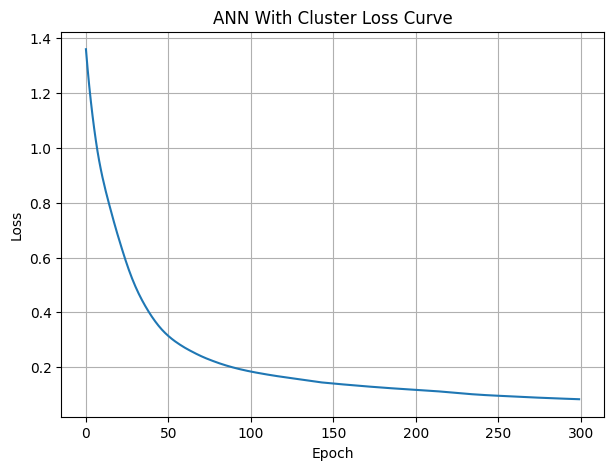

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(ann2.loss_curve_)
plt.title("ANN With Cluster Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Part 4.4: Learning Rate Experiment

I tested different learning rates to see how learning rate affects ANN accuracy and training.

In [16]:
ratelist = [0.001, 0.01, 0.05]
rateanswer = []

for rate in ratelist:
    tempann = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation="relu",
        learning_rate_init=rate,
        max_iter=300,
        random_state=7
    )

    tempann.fit(xtrain, ytrain)
    temppred = tempann.predict(xtest)
    tempacc = accuracy_score(ytest, temppred)

    rateanswer.append([rate, tempacc])

ratetable = pd.DataFrame(rateanswer, columns=["learning rate", "accuracy"])
print(ratetable)

   learning rate  accuracy
0          0.001  0.872727
1          0.010  0.981818
2          0.050  0.945455


### Part 4.5: Hidden Layer Experiment

I tested different hidden layer settings to see how model structure affects performance.

In [17]:
layers = [(5,), (10,), (10, 5), (20, 10)]
layeranswer = []

for layer in layers:
    tempann = MLPClassifier(
        hidden_layer_sizes=layer,
        activation="relu",
        learning_rate_init=0.01,
        max_iter=300,
        random_state=7
    )

    tempann.fit(xtrain, ytrain)
    temppred = tempann.predict(xtest)
    tempacc = accuracy_score(ytest, temppred)

    layeranswer.append([str(layer), tempacc])

layertable = pd.DataFrame(layeranswer, columns=["hidden layer", "accuracy"])
print(layertable)

  hidden layer  accuracy
0         (5,)  0.981818
1        (10,)  0.981818
2      (10, 5)  0.963636
3     (20, 10)  0.963636


### Part 4.6: Activation Function Experiment

I tested ReLU, tanh and logistic activation functions.

In [18]:
activations = ["relu", "tanh", "logistic"]
actanswer = []

for act in activations:
    tempann = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        learning_rate_init=0.01,
        max_iter=300,
        random_state=7
    )

    tempann.fit(xtrain, ytrain)
    temppred = tempann.predict(xtest)
    tempacc = accuracy_score(ytest, temppred)

    actanswer.append([act, tempacc])

acttable = pd.DataFrame(actanswer, columns=["activation", "accuracy"])
print(acttable)

  activation  accuracy
0       relu  0.981818
1       tanh  0.981818
2   logistic  0.963636


## Part 5: Experiments and Comparison

This table shows the main results in one place. It compares clustering only, ANN only, and clustering plus ANN.

In [15]:
finaltable = pd.DataFrame({
    "experiment": ["Clustering Only", "ANN Only", "Clustering + ANN"],
    "accuracy": ["not applicable", annacc, ann2acc],
    "training time": ["not applicable", anntime, ann2time]
})

print(finaltable)

         experiment        accuracy   training time
0   Clustering Only  not applicable  not applicable
1          ANN Only        0.981818        0.161714
2  Clustering + ANN        0.981818        0.107157


## Final Required Questions and Answers

### Question 1: Does clustering improve performance?

In this project, I compared three cases:

1. Clustering only
2. ANN only
3. Clustering and ANN

In the saved result, ANN only and Clustering and ANN give almost the same accuracy. So, in this dataset, clustering does not clearly improve accuracy.

But clustering is still useful because it helps us understand the hidden structure of data. It also gives an extra feature called cluster ID, which can sometimes help ANN learn better.

So the final answer is: clustering did not give a big improvement in this run, but it helped in data understanding and feature augmentation.

### Question 2: When does clustering fail?

Clustering can fail in these cases:

- When the data points are highly mixed
- When clear groups are not present
- When wrong K value is selected
- When features are not scaled properly
- When outliers are present
- When actual class labels do not match natural clusters

For example, if K is too small, different groups may merge together. If K is too large, one group may split into many small groups.

K Means also depends on distance, so scaling is important.

### Question 3: How sensitive is K?

K Means is sensitive to the value of K because K decides how many clusters will be created.

In this notebook, I tested different K values from 2 to 6. For each K, I checked inertia and silhouette score.

A small K can combine separate groups. A large K can divide one natural group into extra groups.

So choosing K carefully is important. In this project, K = 3 was selected because it gave a good clustering result and the dataset was also generated with 3 classes.


## Part 6: Visualization

Cluster plots and loss graphs are already included above. In this final visualization, I made a decision boundary using the 2D PCA values because boundary can be drawn easily in two dimensions.

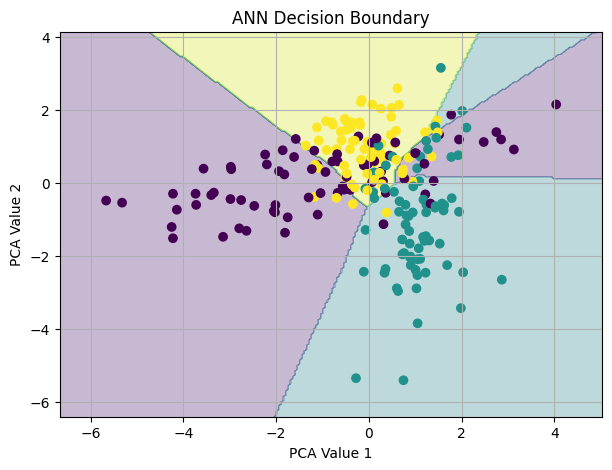

In [19]:
xplot = xview
yplot = ydata

xtrain3, xtest3, ytrain3, ytest3 = train_test_split(
    xplot,
    yplot,
    test_size=0.25,
    random_state=7
)

boundann = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    learning_rate_init=0.01,
    max_iter=300,
    random_state=7
)

boundann.fit(xtrain3, ytrain3)

xmin = xplot[:, 0].min() - 1
xmax = xplot[:, 0].max() + 1
ymin = xplot[:, 1].min() - 1
ymax = xplot[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(xmin, xmax, 0.05),
    np.arange(ymin, ymax, 0.05)
)

grid = np.c_[xx.ravel(), yy.ravel()]
gridans = boundann.predict(grid)
gridans = gridans.reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, gridans, alpha=0.3)
plt.scatter(xplot[:, 0], xplot[:, 1], c=yplot)
plt.title("ANN Decision Boundary")
plt.xlabel("PCA Value 1")
plt.ylabel("PCA Value 2")
plt.grid(True)
plt.show()